# Optional — Build and test one model change

**Outside the four-hour core. Provisional time: 60–90 minutes, to be piloted.**
Use this starter after 02–04 to practise specifying your own small experiment.
Choose one question, draw its boxes/arrows, write the changed equation with units,
run a matched comparison and interpret one figure with conservation evidence.

The supplied starting model is 02's transparent two-layer construction, including
its ratio-derived teaching geometry and explicit mass-based transport. It has
no sediment or weathering boundary. This is a teaching model, not a calibrated
research configuration. Copy the notebook to develop your own design; keep the
course inputs intact.

Code labelled **Choose and explain** contains your decisions; repeated model
construction, integration, plotting and audit code are supplied. Blue questions
mark student work, purple instructor panels give one possible design.
Keep explanations in this ungraded notebook. No separate report is needed.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — specify one testable change**

Choose a bounded question, for example:

- Does fixed versus first-order carbon export produce a different transient when
  both exports agree at a stated reference concentration?
- Does changing the duration of the same finite carbon input change peak CO2
  and its timing? For this option reuse 02's supplied pulse/clock machinery.

State your hypothesis and a result that would challenge it. Draw the modified
arrow, write its equation and units, identify the control, and choose one response
metric and comparison time. Separate prescribed inputs from outputs and explain
which carbon/TA terms cancel. Change one scientific assumption at a time.

The code below supports the export-law option. You may adapt it for your chosen
question. Its matched cases start from the same initial state, not a stationary
restart; do not interpret their early adjustment as a perturbation of equilibrium.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Example: compare fixed export P0 with first-order export k DIC_s(t), choosing
k = P0 / DIC_ref so their initial fluxes agree when DIC_s(0) = DIC_ref.
Both conserve the same carbon and TA because export is an internal DIC transfer.
Hypothesis: as surface DIC falls, the first-order flux weakens relative to fixed
export, producing a less pronounced atmospheric drawdown. Compare atmospheric
CO2 at 1000 years and inspect the difference over the full trajectory.
Use identical initial DIC/TA, geometry, chemistry, circulation and clocks.
This tests the chosen closure inside the model, not whether biology follows it.

</div>
<!-- END SOLUTION -->

In [1]:
# Supplied implementation: environment and reusable two-layer construction.
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / 'teaching_config.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from esbmtk import Species2Species
from teaching_config import TEACHING as config
from simple_models import two_layer, audit, box_mass_kg
from model import run_model

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — choose inputs and implement your changed arrow**

Choose a positive hypothetical reference export and reference concentration,
giving their units and provenance. These are experiment choices, not observations.
Set `reference_export_mol_yr`, `reference_dic_umol_kg`, `comparison_year`,
`run_stop` and `max_timestep`. The reference and changed case use the same values.

Complete the two native connections inside `build_case`. For the export-law option,
both transfer DIC from Surface to Deep; use a fixed amount/time for the reference
and derive the concentration coefficient for the changed case. Concentrations in
the native law are mol/kg, not µmol/kg. Keep the kernel's class signature/documentation
available; syntax memorisation is not the objective.

</div>

In [2]:
# Choose and explain: one possible instructor design is masked for students.
# BEGIN SOLUTION
reference_export_mol_yr = 120e12  # Hypothetical experiment input, mol C/yr.
reference_dic_umol_kg = 2000.0   # Hypothetical common starting concentration.
comparison_year = 1000.0
run_stop, max_timestep = '30 kyr', '20 yr'
# END SOLUTION

def build_case(kind):
    model = two_layer(initial_dic_umol_kg=reference_dic_umol_kg, k_kg_yr=0.0,
                      stop=run_stop, max_timestep=max_timestep, config=config)
    # The helper supplies water/gas arrows and inferred TA; add your one change.
    # BEGIN SOLUTION
    if kind == 'reference':
        model.export_connection = Species2Species(
            source=model.Surface.DIC, sink=model.Deep.DIC,
            ctype='regular', rate=f'{reference_export_mol_yr} mol/yr', id='export')
    elif kind == 'changed':
        k_kg_yr = reference_export_mol_yr / (reference_dic_umol_kg * 1e-6)
        model.export_connection = Species2Species(
            source=model.Surface.DIC, sink=model.Deep.DIC,
            ctype='scale_with_concentration', scale=k_kg_yr, id='export')
    else:
        raise ValueError(kind)
    # END SOLUTION
    return model

cases = {kind: build_case(kind) for kind in ('reference', 'changed')}


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025




ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025



The supplied checks require matching initial carbon/TA and clocks. They audit
each run, not just the difference between runs. If you choose a boundary forcing,
adapt the expected inventory using the integrated input as in 02; do not disable
the conservation test. These checks cannot decide whether the chosen closure is
scientifically adequate.

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.50 CPU seconds, wall time = 0.51 seconds


There were 18 warnings, check M.log




status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 3.34 CPU seconds, wall time = 3.38 seconds


There were 17 warnings, check M.log




,carbon_relative_error,ta_change_mol
reference,1.424958e-15,0.0
changed,2.849915e-15,0.0


Changed minus reference at 1000.0 yr: 2.5871607440317854 ppm


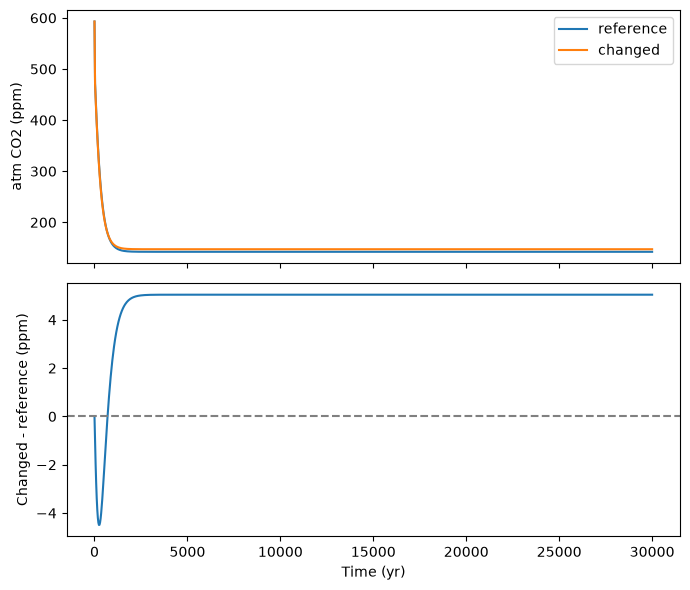

In [3]:
# Understand and run: supplied execution, budgets, metric and figure.
np.testing.assert_allclose(cases['reference'].time, cases['changed'].time)
def initial_inventory(case):
    # Before integration, native array lengths need not yet match; use scalars.
    carbon = case.CO2_At.c[0] * case.CO2_At.reservoir_mass.to('mol').magnitude
    ta = 0.0
    for box in case.ocean_boxes:
        carbon += box_mass_kg(box) * box.DIC.c[0]
        ta += box_mass_kg(box) * box.TA.c[0]
    return carbon, ta
np.testing.assert_allclose(initial_inventory(cases['reference']),
                           initial_inventory(cases['changed']), rtol=1e-12)
reports = {}
for name, case in cases.items():
    run_model(case)
    reports[name] = audit(case)
display(pd.DataFrame(reports).T)
ref, changed = cases['reference'], cases['changed']
if not ref.time[0] <= comparison_year <= ref.time[-1]:
    raise ValueError('Comparison time must lie inside the run')
delta = (changed.CO2_At.c - ref.CO2_At.c) * 1e6
print('Changed minus reference at', comparison_year, 'yr:',
      float(np.interp(comparison_year, ref.time, delta)), 'ppm')
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
for name, case in cases.items():
    axes[0].plot(case.time, case.CO2_At.c * 1e6, label=name)
axes[0].set_ylabel('atm CO2 (ppm)')
axes[0].legend()
axes[1].plot(ref.time, delta)
axes[1].axhline(0, color='gray', ls='--')
axes[1].set(xlabel='Time (yr)', ylabel='Changed - reference (ppm)')
fig.tight_layout()
plt.show()

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — interpret and identify the next evidence needed**

Use your chosen metric and one feature of the figure to assess the hypothesis.
Explain the controlling flux balance and one limitation. Distinguish transient
adjustment from an established stationary response. Name an independent observation
or constraint that would help evaluate the closure, and one sensitivity or numerical
resolution check needed before a research claim. You need not run a large parameter
sweep in this starter.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

For the supplied example the changed case has a higher atmospheric CO2 after
the initial adjustment because its export weakens as surface DIC decreases.
Both conserve total carbon/TA, so the atmospheric difference is redistribution.
The fixed export is not limited by nutrients and can become unrealistic outside
this tested range. Compare export observations with compatible depths and units
independently of any fitted concentration target. Test numerical resolution and
the reference flux/concentration choice before interpreting a general biological
effect. A plot ending at 30 kyr alone is not proof of stationarity.

</div>
<!-- END SOLUTION -->

**Keep the experiment specification with the code and figure.** ESM research will
also require spatial diagnostics, uncertainty and internal-variability/ensemble
analysis; this deterministic comparison is a starting exercise.